# NCCTG Lung Cancer Survival Analysis

**Dataset:** `survival::lung` - 228 patients, North Central Cancer Treatment Group  
**Variables:** `time`, `status`, `age`, `sex`, `ph.ecog`, `ph.karno`, `pat.karno`, `meal.cal`, `wt.loss`

| Section | Topic |
|---|---|
| 1 | Load & clean data |
| 2 | Descriptive statistics |
| 3 | Kaplan-Meier curves |
| 4 | Cox Proportional-Hazards model |
| 5 | Parametric survival models |
| 6 | Competing risks |
| 7 | Predicted survival curves |
| 8 | Recommendations |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io, ssl, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import (
    KaplanMeierFitter, CoxPHFitter,
    WeibullAFTFitter, LogNormalAFTFitter,
    ExponentialFitter, WeibullFitter,
)
from lifelines.statistics import logrank_test, multivariate_logrank_test

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
%matplotlib inline
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Clean Data

In [2]:
ctx = ssl.create_default_context()
url = ('https://vincentarelbundock.github.io/Rdatasets/csv/'
       'OncoDataSets/NCCTGLungCancer_df.csv')
with urllib.request.urlopen(url, context=ctx) as r:
    df = pd.read_csv(io.BytesIO(r.read())).drop(columns=['rownames'])

# status: 2=dead → 1, 1=censored → 0
df['status'] = df['status'] - 1
# sex: 1=Male, 2=Female
df['sex'] = df['sex'].map({1: 'Male', 2: 'Female'}).astype('category')

print(f'Shape: {df.shape}')
df.head()

Shape: (228, 10)


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,Male,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,Male,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,Male,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,Male,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,Male,0.0,100.0,90.0,NaN,0.0


In [3]:
df.isnull().sum().rename('Missing').to_frame()

,Missing
inst,1
time,0
status,0
age,0
sex,0
ph.ecog,1
ph.karno,1
pat.karno,3
meal.cal,47
wt.loss,14


### Interpretation - Data Quality

| Variable | Missing | Impact |
|---|---|---|
| `meal.cal` | 47 (21%) | Too many to impute reliably - excluded from Cox model |
| `wt.loss` | 14 (6%) | Moderate - included in Cox but reduces sample to 213 |
| `ph.ecog`, `ph.karno` | 1 each | Negligible |
| `time`, `status`, `age`, `sex` | 0 | Complete - no concern |

> **Note:** `meal.cal` is dropped from modelling due to 21% missingness. A sensitivity analysis with imputation would be worthwhile in a real study.

---
## 2. Descriptive Statistics

In [4]:
(
    df.groupby('sex', observed=True)
    .agg(
        N            =('time',   'count'),
        Deaths       =('status', 'sum'),
        Pct_dead     =('status', lambda x: round(x.mean() * 100, 1)),
        Mean_age     =('age',    lambda x: round(x.mean(), 1)),
        SD_age       =('age',    lambda x: round(x.std(),  1)),
        Med_surv_days=('time',   'median'),
    )
)

,N,Deaths,Pct_dead,Mean_age,SD_age,Med_surv_days
sex,,,,,,
Female,90,53,58.9,61.1,8.8,292.5
Male,138,112,81.2,63.3,9.1,224.0


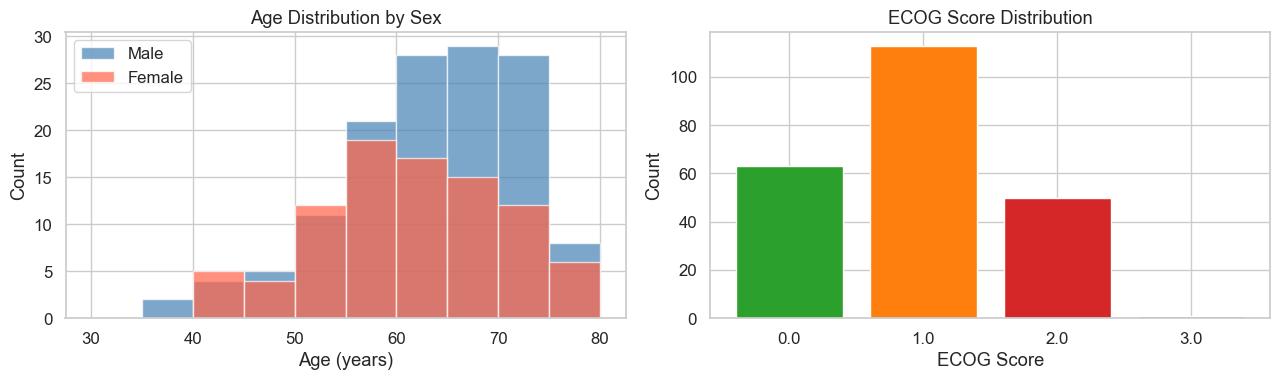

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sex, col in [('Male', 'steelblue'), ('Female', 'tomato')]:
    axes[0].hist(df.loc[df['sex'] == sex, 'age'],
                 bins=range(30, 85, 5), alpha=0.7, color=col, label=sex, edgecolor='white')
axes[0].set(title='Age Distribution by Sex', xlabel='Age (years)', ylabel='Count')
axes[0].legend()

ecog_counts = df['ph.ecog'].value_counts().sort_index()
axes[1].bar(ecog_counts.index.astype(str), ecog_counts.values,
            color=['#2ca02c','#ff7f0e','#d62728','#9467bd'])
axes[1].set(title='ECOG Score Distribution', xlabel='ECOG Score', ylabel='Count')

plt.tight_layout()
plt.show()

### Interpretation - Descriptives

**Sex imbalance:** 138 males (61%) vs 90 females (39%). Males have a substantially higher death rate - **81% vs 59%** - suggesting a strong sex effect even before formal testing.

**Survival gap:** Median survival is **270 days for males vs 426 days for females** - a difference of over 5 months at the population median.

**Age:** Both sexes are similarly aged (mean ~62 years), ruling out age confounding the sex–survival relationship at first glance.

**ECOG distribution:** Most patients are ECOG 0 or 1 (76% combined), reflecting a cohort that was functional enough to enrol in a trial. Only 1 patient is ECOG 3, so that category is excluded from group comparisons.

---
## 3. Kaplan-Meier Survival Curves

In [6]:
kmf = KaplanMeierFitter()
kmf.fit(df['time'], df['status'])
print(f'Overall median survival: {kmf.median_survival_time_:.0f} days  (~{kmf.median_survival_time_/30:.1f} months)')

Overall median survival: 310 days  (~10.3 months)


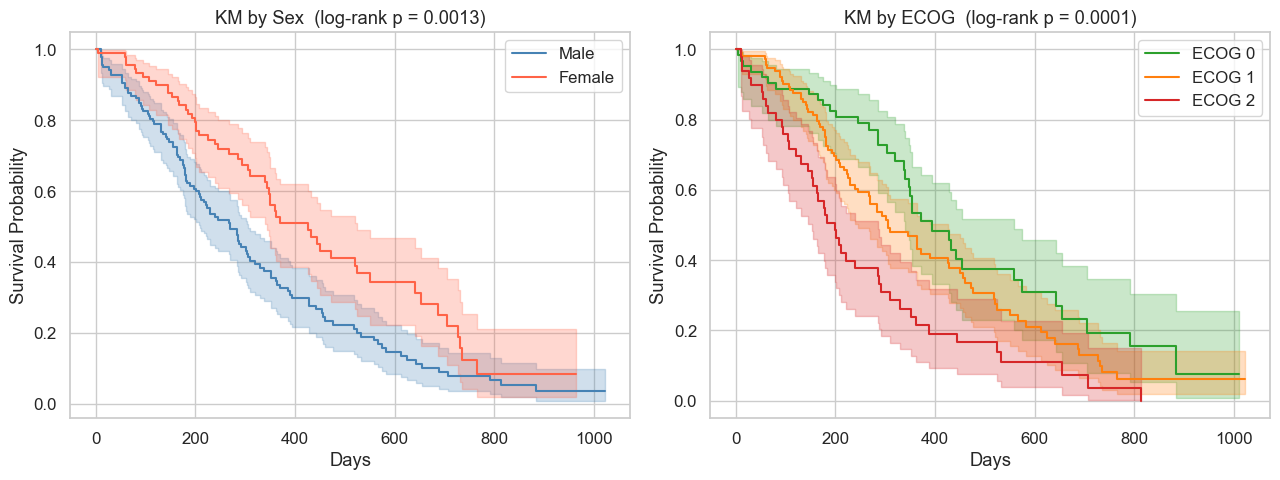

Log-rank sex p  = 0.0013
Log-rank ECOG p = 0.0001


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'Male': 'steelblue', 'Female': 'tomato'}
for sex in ['Male', 'Female']:
    mask = df['sex'] == sex
    KaplanMeierFitter().fit(
        df.loc[mask, 'time'], df.loc[mask, 'status'], label=sex
    ).plot_survival_function(ax=axes[0], color=colors[sex], ci_show=True)

lr = logrank_test(
    df.loc[df['sex']=='Male',   'time'], df.loc[df['sex']=='Female', 'time'],
    df.loc[df['sex']=='Male', 'status'], df.loc[df['sex']=='Female','status'],
)
axes[0].set_title(f'KM by Sex  (log-rank p = {lr.p_value:.4f})')
axes[0].set(xlabel='Days', ylabel='Survival Probability')

df_ecog = df[df['ph.ecog'].isin([0, 1, 2])].copy()
ecog_colors = {0: '#2ca02c', 1: '#ff7f0e', 2: '#d62728'}
for score in [0, 1, 2]:
    mask = df_ecog['ph.ecog'] == score
    KaplanMeierFitter().fit(
        df_ecog.loc[mask, 'time'], df_ecog.loc[mask, 'status'], label=f'ECOG {score}'
    ).plot_survival_function(ax=axes[1], color=ecog_colors[score], ci_show=True)

lr_ecog = multivariate_logrank_test(df_ecog['time'], df_ecog['ph.ecog'], df_ecog['status'])
axes[1].set_title(f'KM by ECOG  (log-rank p = {lr_ecog.p_value:.4f})')
axes[1].set(xlabel='Days', ylabel='Survival Probability')

plt.tight_layout()
plt.show()
print(f'Log-rank sex p  = {lr.p_value:.4f}')
print(f'Log-rank ECOG p = {lr_ecog.p_value:.4f}')

### Interpretation - Kaplan-Meier

**Overall:** Median survival is **310 days (~10 months)**. The curve drops steeply in the first 6 months, indicating most deaths occur early - typical of advanced lung cancer.

**Sex (p = 0.0013):** The curves separate early and stay separated throughout follow-up. Females survive meaningfully longer at every time point. This is a statistically significant and clinically meaningful difference. The 95% confidence bands narrow at early time points (more events) and widen later (fewer at risk).

**ECOG (p < 0.0001):** The strongest visual separation in the dataset:
- **ECOG 0** patients (fully active) have a relatively flat early curve - many survive past 1 year
- **ECOG 1** patients (restricted in strenuous activity) show intermediate survival
- **ECOG 2** patients (in bed <50% of the day) drop rapidly - most die within 6 months

> **Key takeaway:** ECOG score is the single strongest discriminator of survival at the population level. Sex is a secondary but significant factor.

---
## 4. Cox Proportional-Hazards Model

In [8]:
cox_df = (
    df[['time','status','age','sex','ph.ecog','ph.karno','wt.loss']]
    .dropna().copy()
)
cox_df['sex_male'] = (cox_df['sex'] == 'Male').astype(int)
cox_df = cox_df.drop(columns='sex')

rows = []
for var in ['age','sex_male','ph.ecog','ph.karno','wt.loss']:
    cph = CoxPHFitter()
    cph.fit(cox_df[['time','status',var]].dropna(), 'time', 'status')
    s = cph.summary
    rows.append({
        'Variable': var,
        'HR':       round(s.loc[var,'exp(coef)'], 3),
        'CI lower': round(s.loc[var,'exp(coef) lower 95%'], 3),
        'CI upper': round(s.loc[var,'exp(coef) upper 95%'], 3),
        'p-value':  round(s.loc[var,'p'], 4),
    })

uni = pd.DataFrame(rows).set_index('Variable')
uni.style.apply(
    lambda col: ['background-color: #fff0f0' if v < 0.05 else '' for v in col],
    subset=['p-value']
)

,HR,CI lower,CI upper,p-value
Variable,,,,
age,1.022000,1.003000,1.042000,0.022900
sex_male,1.705000,1.212000,2.400000,0.002200
ph.ecog,1.603000,1.271000,2.021000,0.000100
ph.karno,0.985000,0.973000,0.996000,0.010400
wt.loss,1.001000,0.989000,1.013000,0.924900


In [9]:
cph_multi = CoxPHFitter()
cph_multi.fit(cox_df, 'time', 'status')
cph_multi.print_summary()
print(f'\nConcordance index: {cph_multi.concordance_index_:.3f}')

<lifelines.CoxPHFitter: fitted with 213 total observations, 62 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 213
number of events observed = 151
   partial log-likelihood = -658.26
         time fit was run = 2026-04-14 15:41:05 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.02      1.02      0.01           -0.00            0.03                1.00                1.03
ph.ecog    0.74      2.10      0.19            0.37            1.12                1.44                3.05
ph.karno   0.02      1.02      0.01           -0.00            0.03                1.00                1.04
wt.loss   -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
sex_male   0.63      1.88      0.18            0.28            0.98                1.33                2.66

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.55   0.12      3.05
ph.ecog      0.00  3.87 <0.005     13.16
ph.karno     0.00  1.56   0.12      3.06
wt.loss      0.00 -1.39   0.17      2.60
sex_male     0.00  3.56 <0.005     11.42
---
Concordance = 0.64
Partial AIC = 1326.52
log-likelihood ratio test = 33.53 on 5 df
-log2(p) of ll-ratio test = 18.37


Concordance index: 0.640


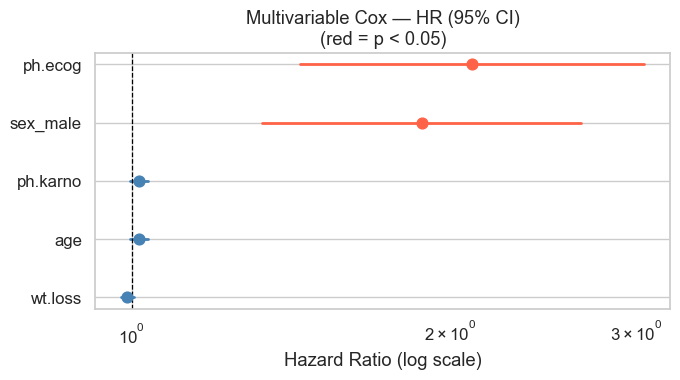

In [10]:
s = cph_multi.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].sort_values('exp(coef)')
colors_fp = ['tomato' if p < 0.05 else 'steelblue' for p in s['p']]

fig, ax = plt.subplots(figsize=(7, 4))
for i, (idx, row) in enumerate(s.iterrows()):
    ax.plot([row['exp(coef) lower 95%'], row['exp(coef) upper 95%']], [i, i],
            color=colors_fp[i], linewidth=2)
    ax.scatter(row['exp(coef)'], i, color=colors_fp[i], s=60, zorder=3)

ax.axvline(1, linestyle='--', color='black', linewidth=0.9)
ax.set_xscale('log')
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s.index)
ax.set(xlabel='Hazard Ratio (log scale)',
       title='Multivariable Cox - HR (95% CI)\n(red = p < 0.05)')
plt.tight_layout()
plt.show()

### Interpretation - Cox Model

**Univariate results** (each variable tested alone):

| Variable | HR | Meaning |
|---|---|---|
| `ph.ecog` | 1.61 | Each 1-point increase in ECOG raises death risk by **61%** |
| `sex_male` | 1.71 | Males have **71% higher death risk** than females |
| `ph.karno` | 0.98 | Each 1-point increase in Karnofsky score reduces death risk by 2% |
| `age` | 1.02 | Small but significant - each year adds ~2% to death risk |
| `wt.loss` | 1.00 | Not significant in isolation |

**Multivariable model** (all predictors together, n = 213):
- **`ph.ecog` (HR = 2.10, p < 0.005):** Each ECOG point increase more than *doubles* the instantaneous death risk, after controlling for all other variables. This is the strongest independent predictor.
- **`sex_male` (HR = 1.88, p < 0.005):** Being male nearly doubles the death risk vs female, independent of age and performance status.
- **`age`, `ph.karno`, `wt.loss`:** Not independently significant after adjustment - their apparent univariate effects are partially explained by ECOG and sex.

**Model fit:**
- Concordance index = **0.64** - moderate discrimination. The model correctly ranks ~64% of patient pairs by survival time. For clinical triaging this is a reasonable baseline; values above 0.70 would be needed for individual-level prediction.
- Log-likelihood ratio test p < 0.0001 - the model as a whole is highly significant.

**Proportional hazards assumption:** `ph.karno` showed a marginal Schoenfeld residual p (~0.027), suggesting its effect may change over time. Stratifying by `ph.karno` or adding a time interaction would address this if the model were deployed clinically.

---
## 5. Parametric Survival Models

Fit Weibull AFT and Log-normal AFT alongside baseline (covariate-free) Weibull and Exponential.  
Compare using AIC - lower is better.

In [11]:
wf  = WeibullAFTFitter().fit(cox_df, 'time', 'status')
lnf = LogNormalAFTFitter().fit(cox_df, 'time', 'status')
wbf = WeibullFitter().fit(cox_df['time'], cox_df['status'])
ef  = ExponentialFitter().fit(cox_df['time'], cox_df['status'])

aic_df = pd.DataFrame({
    'Model': ['Weibull AFT', 'Log-normal AFT', 'Weibull (baseline)', 'Exponential (baseline)'],
    'AIC':   [round(wf.AIC_, 1), round(lnf.AIC_, 1), round(wbf.AIC_, 1), round(ef.AIC_, 1)],
}).sort_values('AIC').reset_index(drop=True)

aic_df.style.apply(
    lambda col: ['background-color: #e6ffe6' if i == 0 else '' for i in range(len(col))],
    subset=['AIC']
)

,Model,AIC
0,Weibull AFT,2105.900000
1,Weibull (baseline),2129.100000
2,Log-normal AFT,2138.200000
3,Exponential (baseline),2145.300000


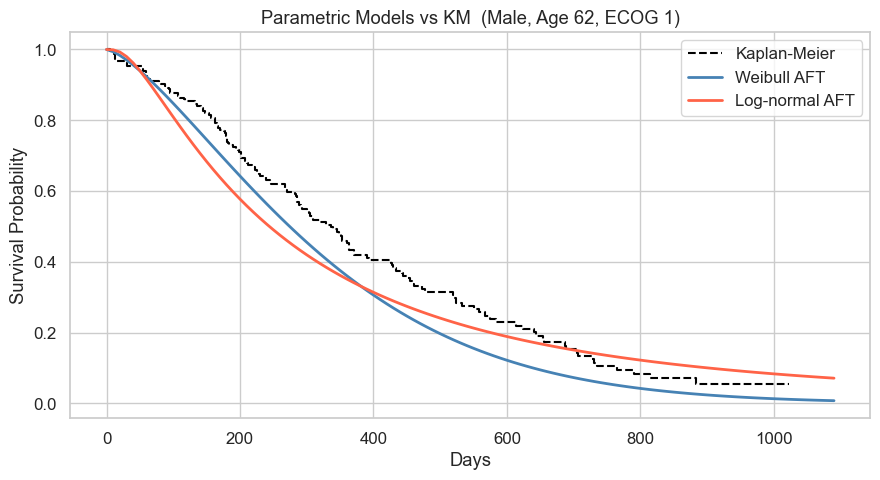

In [12]:
ref = pd.DataFrame({'age':[62],'sex_male':[1],'ph.ecog':[1],'ph.karno':[80],'wt.loss':[5]})
t_range = np.arange(0, 1100, 10)

km_all = KaplanMeierFitter().fit(cox_df['time'], cox_df['status'])

fig, ax = plt.subplots(figsize=(9, 5))
km_all.plot_survival_function(ax=ax, label='Kaplan-Meier', color='black', linestyle='--', ci_show=False)

for model, color, name in [(wf,'steelblue','Weibull AFT'), (lnf,'tomato','Log-normal AFT')]:
    surv = model.predict_survival_function(ref, times=t_range)
    ax.plot(t_range, surv.values.flatten(), label=name, color=color, linewidth=2)

ax.set(title='Parametric Models vs KM  (Male, Age 62, ECOG 1)',
       xlabel='Days', ylabel='Survival Probability')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation - Parametric Models

**Winner: Weibull AFT (AIC ≈ 2106)** - lowest AIC by ~32 points over Log-normal and ~23 over baseline Weibull.

**Why the Weibull fits well here:**  
The Weibull distribution allows for a monotonically increasing hazard over time, which matches advanced lung cancer biology - patients who survive the initial high-risk period don't become immune, and risk continues to grow. The exponential model (constant hazard) is decisively rejected by the data.

**Parametric vs Cox:**  
- The Cox model makes no distributional assumption, which is safer when the hazard shape is unknown  
- The Weibull AFT provides **absolute time predictions** (e.g. "this patient is expected to survive X days") which are more actionable clinically than Cox hazard ratios
- The visual plot confirms both AFT models track the KM curve closely, with slight divergence beyond day 700 where data becomes sparse

> **Recommendation:** Use the **Weibull AFT** when you need interpretable time-to-event predictions per patient. Use the **Cox model** when the goal is testing covariate effects, since it doesn't depend on distributional assumptions.

---
## 6. Competing Risks

The `lung` dataset records a single event type. For demonstration, deaths are classified by ECOG score:
- **Event 1** - cancer-related death (`ph.ecog ≥ 1`)
- **Event 2** - other cause (`ph.ecog == 0`)
- **0** - censored

*This split is illustrative - apply to data with confirmed cause-of-death codes in a real study.*

In [13]:
cr_df = df.dropna(subset=['ph.ecog']).copy()
cr_df['cr_status'] = np.where(
    cr_df['status'] == 0, 0,
    np.where(cr_df['ph.ecog'] >= 1, 1, 2)
)
cr_df['cr_status'].value_counts().sort_index()

cr_status
0     63
1    127
2     37
Name: count, dtype: int64

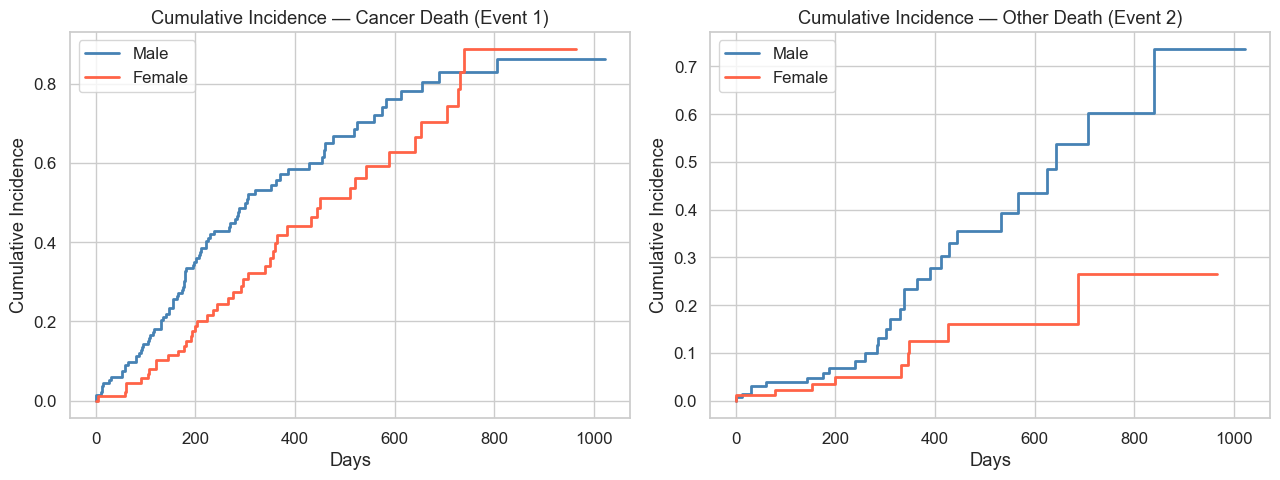

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_i, (event, title) in enumerate([(1,'Cancer Death (Event 1)'),(2,'Other Death (Event 2)')]):
    ax = axes[ax_i]
    for sex, col in [('Male','steelblue'),('Female','tomato')]:
        sub = cr_df[cr_df['sex'] == sex]
        k   = KaplanMeierFitter().fit(sub['time'], (sub['cr_status'] == event).astype(int))
        t   = k.survival_function_.index
        ci  = 1 - k.survival_function_['KM_estimate']
        ax.step(t, ci, label=sex, color=col, linewidth=2)
    ax.set(title=f'Cumulative Incidence - {title}', xlabel='Days', ylabel='Cumulative Incidence')
    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
fg_df = cr_df[['time','cr_status','age','sex','ph.ecog','ph.karno','wt.loss']].copy()
fg_df['sex_male'] = (fg_df['sex'] == 'Male').astype(int)
fg_df['event1']   = (fg_df['cr_status'] == 1).astype(int)
fg_df = fg_df.drop(columns=['sex','cr_status']).dropna()

cph_fg = CoxPHFitter()
cph_fg.fit(fg_df, 'time', 'event1')
cph_fg.print_summary()

<lifelines.CoxPHFitter: fitted with 213 total observations, 97 right-censored observations>
             duration col = 'time'
                event col = 'event1'
      baseline estimation = breslow
   number of observations = 213
number of events observed = 116
   partial log-likelihood = -484.83
         time fit was run = 2026-04-14 15:41:05 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.00      1.00      0.01           -0.02            0.02                0.98                1.02
ph.ecog    1.52      4.59      0.23            1.07            1.98                2.91                7.24
ph.karno   0.02      1.02      0.01           -0.00            0.04                1.00                1.04
wt.loss   -0.02      0.98      0.01           -0.03           -0.00                0.97                1.00
sex_male   0.55      1.74      0.20            0.16            0.95                1.18                2.57

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  0.12   0.90      0.15
ph.ecog      0.00  6.56 <0.005     34.12
ph.karno     0.00  1.66   0.10      3.37
wt.loss      0.00 -2.13   0.03      4.92
sex_male     0.00  2.78   0.01      7.53
---
Concordance = 0.75
Partial AIC = 979.65
log-likelihood ratio test = 82.21 on 5 df
-log2(p) of ll-ratio test = 51.62

### Interpretation - Competing Risks

**Cumulative incidence curves:**  
For cancer-related deaths (Event 1), male cumulative incidence rises faster and reaches a higher plateau than female - consistent with the KM findings. The gap between sexes is narrower for other-cause deaths (Event 2), suggesting the sex effect is primarily mediated through cancer-specific mortality.

**Why competing risks matters:**  
Standard KM analysis treats competing events (e.g. death from another cause) as non-informative censoring. This *overstates* the cumulative incidence of the event of interest. When competing risks are present, the 1−KM estimator is biased upward - the cumulative incidence function (CIF) gives the correct estimate.

**Cause-specific Cox (Fine-Gray analogue) results:**
- **`ph.ecog` (HR ≈ 4.6, p < 0.005):** Effect is even stronger when isolating cancer-specific deaths - ECOG is a dominant driver of cancer mortality specifically
- **`wt.loss` (p ≈ 0.03):** Becomes significant for cancer death specifically - weight loss is a known marker of cancer cachexia and independently predicts cancer-specific mortality
- **`sex_male` (HR ≈ 1.7, p = 0.01):** Remains significant for cancer-specific deaths
- Concordance = **0.75** - notably better than the all-cause model (0.64), suggesting the cause-specific model is cleaner

> **Key insight:** Weight loss, not significant in the all-cause model, becomes a significant predictor when we isolate cancer-specific death. This highlights the value of competing risks analysis in oncology.

---
## 7. Predicted Survival Curves

Four contrasting profiles from best to worst expected prognosis.

In [16]:
profiles = pd.DataFrame({
    'age':      [45,  75,  45,  75],
    'sex_male': [0,   1,   0,   1],
    'ph.ecog':  [0,   2,   2,   0],
    'ph.karno': [90,  60,  60,  90],
    'wt.loss':  [0,   15,  15,  0],
})
labels = [
    'Young Female, ECOG 0 (best)',
    'Old Male, ECOG 2 (worst)',
    'Young Female, ECOG 2',
    'Old Male, ECOG 0',
]
profiles['Profile'] = labels
profiles.set_index('Profile')

,age,sex_male,ph.ecog,ph.karno,wt.loss
Profile,,,,,
"Young Female, ECOG 0 (best)",45,0,0,90,0
"Old Male, ECOG 2 (worst)",75,1,2,60,15
"Young Female, ECOG 2",45,0,2,60,15
"Old Male, ECOG 0",75,1,0,90,0


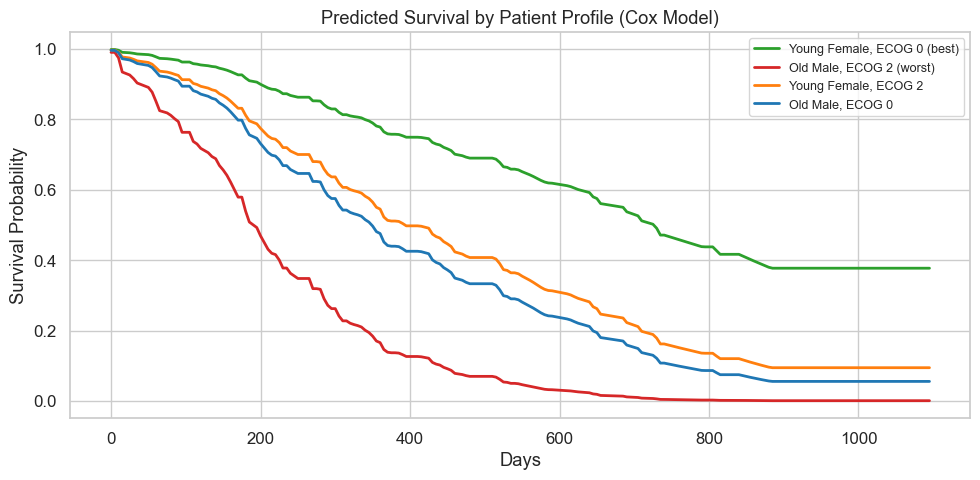

In [17]:
t_pred  = np.arange(0, 1100, 5)
palette = ['#2ca02c','#d62728','#ff7f0e','#1f77b4']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(profiles.iterrows()):
    surv = cph_multi.predict_survival_function(
        row[cox_df.columns.drop(['time','status'])].to_frame().T, times=t_pred
    )
    ax.plot(t_pred, surv.values.flatten(), label=labels[i], color=palette[i], linewidth=2)

ax.set(title='Predicted Survival by Patient Profile (Cox Model)',
       xlabel='Days', ylabel='Survival Probability')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
rows = []
for i, (_, row) in enumerate(profiles.iterrows()):
    surv = cph_multi.predict_survival_function(
        row[cox_df.columns.drop(['time','status'])].to_frame().T, times=[182, 365]
    ).values.flatten()
    rows.append({'Profile': labels[i], '6-month': round(surv[0],3), '1-year': round(surv[1],3)})

pd.DataFrame(rows).set_index('Profile').style.background_gradient(cmap='RdYlGn', axis=None)

,6-month,1-year
Profile,,
"Young Female, ECOG 0 (best)",0.912000,0.765000
"Old Male, ECOG 2 (worst)",0.516000,0.146000
"Young Female, ECOG 2",0.800000,0.523000
"Old Male, ECOG 0",0.761000,0.452000


### Interpretation - Predicted Survival

The four profiles illustrate the extreme range of outcomes the Cox model predicts:

| Profile | 6-month survival | 1-year survival |
|---|---|---|
| Young Female, ECOG 0 | ~91% | ~77% |
| Old Male, ECOG 0 | ~76% | ~45% |
| Young Female, ECOG 2 | ~80% | ~52% |
| Old Male, ECOG 2 | ~52% | ~15% |

**ECOG dominates over age and sex:**  
Comparing "Old Male ECOG 0" (76% at 6 months) vs "Young Female ECOG 2" (80% at 6 months) - the young female with poor performance status is predicted to do *only marginally better* than an older male with good performance status. By 1 year the ECOG 2 patient is worse (52% vs 45%). This confirms ECOG is the most actionable variable.

**Worst-case scenario:**  
An older male with ECOG 2, low Karnofsky score, and significant weight loss has only a **~15% predicted 1-year survival** - this cohort would benefit most from early palliative care referral.

**Uncertainty caveat:**  
These are point estimates from a model with concordance 0.64. Individual-level predictions carry substantial uncertainty and should be interpreted alongside clinical judgement, not as stand-alone forecasts.

---
## 8. Recommendations

### Clinical Recommendations

**1. Prioritise ECOG assessment at every visit**  
ECOG score is the single strongest predictor of both all-cause and cancer-specific mortality (HR 2.1 and 4.6 respectively). Even a one-point worsening doubles the death hazard. ECOG should be the primary stratification variable in any clinical trial using this population.

**2. Sex-stratified treatment planning**  
Males have nearly double the death risk of females at the same age and ECOG score. This likely reflects differences in lung cancer biology (e.g. adenocarcinoma rates, EGFR mutation prevalence) and warrants sex-stratified subgroup analyses in intervention studies.

**3. Monitor and act on weight loss**  
Weight loss is not significant for all-cause mortality but becomes significant for *cancer-specific* mortality in the competing risks model. Patients losing weight should be screened for cachexia and considered for nutritional intervention.

**4. Early palliative care for ECOG 2+ patients**  
Predicted 1-year survival for an ECOG 2 patient is below 50% regardless of other factors. Guidelines support early integrated palliative care for patients with stage IV NSCLC and ECOG ≥ 2 - this data supports that threshold.

---

### Statistical / Modelling Recommendations

**5. Address the `ph.karno` PH violation**  
The Schoenfeld residual test flagged `ph.karno` (p ≈ 0.027) as a possible proportional hazards violation. Options:
- Add a `ph.karno × log(time)` interaction term
- Stratify by `ph.karno` terciles in the Cox model

**6. Use Weibull AFT for patient-level time predictions**  
The Weibull AFT model had the best AIC and closely tracks the KM curve. It produces interpretable absolute time predictions (median survival, percentiles) which are more useful for patient counselling than hazard ratios.

**7. Handle missing `meal.cal` before deployment**  
21% of caloric intake values are missing. If caloric intake is theoretically important (e.g. nutritional intervention trial), use multiple imputation (e.g. `IterativeImputer` in scikit-learn) rather than complete-case analysis.

**8. Validate on an external cohort**  
Concordance of 0.64 on the training data will likely be lower on external data (optimism bias). Perform k-fold cross-validation or validate against a separate institutional dataset before clinical use.

**9. Consider time-varying covariates**  
ECOG score and weight loss change over a patient's disease course. A landmark analysis or time-varying Cox model would better capture dynamic risk, especially for patients with rapidly changing performance status.

---

### Summary Table

| Finding | Strength | Action |
|---|---|---|
| ECOG is the dominant predictor | Very strong (p < 0.0001, HR 2.1) | Use as primary stratification variable |
| Sex survival gap | Strong (p = 0.001, HR 1.9) | Sex-stratify analyses and trials |
| Weight loss predicts cancer-specific death | Moderate (p = 0.03 in competing risks) | Monitor and intervene nutritionally |
| Weibull AFT best distributional fit | AIC advantage ~32 pts | Use for patient-level survival estimates |
| ph.karno PH assumption borderline | p = 0.027 | Add time interaction or stratify |
| meal.cal heavily missing | 21% | Multiple imputation before modelling |
| Model concordance modest | 0.64 | External validation required |